In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

In [2]:
def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_low, noise_high):
    signals=[]
    for i in tqdm(range(0, N)):
        noise_lvl = np.random.uniform(noise_low, noise_high)
        fake_base = [noise_lvl] * len(freqs)
        fake_signal = random(fake_base)
        signals.append(fake_signal)
    
    # Convert the whole thing to a NumPy array before returning
    return np.array(signals)

In [3]:
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772


In [4]:
def sliding_acf_search(frequency, power_flat, numax_grid,
                       k_width=4.0,
                       lag_frac=(0.8, 1.2)):

    acf_strength = []
    acf_strength_notSNR = []

    df = frequency[1] - frequency[0]

    for nu_c in numax_grid:

        dnu = delta_nu_from_numax(nu_c)
        W = k_width * dnu

        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)

        if mask.sum() < 20:
            acf_strength.append(0.0)
            acf_strength_notSNR.append(0.0)
            continue

        p = power_flat[mask]
        p = p / np.median(p)

        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size // 2:]

        lag = np.arange(acf.size) * df
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)

        signal = np.max(acf[lag_mask])
        noise = np.median(acf[~lag_mask])
        sigma = np.std(acf[~lag_mask])

        SNR = (signal - noise) / sigma

        acf_strength.append(SNR)
        acf_strength_notSNR.append(signal)

    return np.array(acf_strength), np.array(acf_strength_notSNR)


In [5]:
def get_mode_envelope_mask(freq, power, delta_nu_est, numax_est):

    nu_max = numax_est
    fwhm_env = 0.66 * (nu_max ** 0.88)
    sigma_env = fwhm_env / 2.355

    lower = max(0, nu_max - 4 * sigma_env)
    upper = nu_max + 4 * sigma_env

    mask = (freq >= lower) & (freq <= upper)

    return freq[mask], power[mask]


In [6]:
def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.2):

    main_lo = delta_nu_est * (1 - window_frac)
    main_hi = delta_nu_est * (1 + window_frac)

    half_lo = 0.5 * delta_nu_est * (1 - window_frac)
    half_hi = 0.5 * delta_nu_est * (1 + window_frac)

    three_half_lo = 1.5 * delta_nu_est * (1 - window_frac)
    three_half_hi = 1.5 * delta_nu_est * (1 + window_frac)

    mask = (
        (lags > main_lo) & (lags < main_hi) &
        ~((lags > half_lo) & (lags < half_hi)) &
        ~((lags > three_half_lo) & (lags < three_half_hi))
    )

    return lags[mask], acf[mask]


In [7]:
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c

# def run_full_pipeline(freq, power, return_diagnostics=False):
#     diagnostics = {}
#     df = freq[1] - freq[0]
#     smooth_width_bins = int(600 / df)

#     # --- Phase 1: NuMax Search ---
#     background = uniform_filter1d(power, size=smooth_width_bins)
#     power_flat = power / background

#     numax_grid = np.linspace(50, 5000, 100)
#     acf_snr, acf_raw = sliding_acf_search(freq, power_flat, numax_grid)

#     valid = acf_snr >= 3.0
#     diagnostics.update({
#         "numax_grid": numax_grid,
#         "acf_snr": acf_snr,
#         "acf_raw": acf_raw,
#         "valid": valid
#     })

#     if not np.any(valid):
#         diagnostics["status"] = "REJECTED: no SNR peak"
#         return (False, diagnostics) if return_diagnostics else False

#     raw_masked = np.copy(acf_raw)
#     raw_masked[~valid] = 0.0
#     imax = np.argmax(raw_masked)
    
#     numax_est = numax_grid[imax]
#     delta_nu_est = delta_nu_from_numax(numax_est)

#     exclude = 5
#     mask = np.ones_like(acf_raw, dtype=bool)
#     mask[max(0, imax-exclude):imax+exclude+1] = False
#     mask &= valid

#     second_peak = np.max(acf_raw[mask]) if np.any(mask) else None
#     peak_ratio_numax = acf_raw[imax] / (second_peak if second_peak else 1e-6)

#     diagnostics.update({
#         "imax": imax,
#         "numax_est": numax_est,
#         "delta_nu_est": delta_nu_est,
#         "exclude": exclude,
#         "second_peak": second_peak,
#         "numax_peak_ratio": peak_ratio_numax
#     })

#     if peak_ratio_numax < 1.2:
#         diagnostics["status"] = "REJECTED: ambiguous νmax"
#         return (False, diagnostics) if return_diagnostics else False

#     # --- Phase 2: DeltaNu Search ---
#     freq_sel, power_sel = get_mode_envelope_mask(freq, power, delta_nu_est, numax_est)
    
#     if len(freq_sel) < 50:
#         diagnostics["status"] = "REJECTED: envelope too small"
#         return (False, diagnostics) if return_diagnostics else False
    
#     background_sel = uniform_filter1d(power_sel, size=smooth_width_bins)
#     power_flat_sel = power_sel / background_sel
#     signal = power_flat_sel - np.mean(power_flat_sel)
    
#     acf = np.correlate(signal, signal, mode="full")
#     acf = acf[len(signal)-1:]
#     acf /= acf[0]
#     lags = np.arange(len(acf)) * df
    
#     lags_fit, acf_fit = mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.15)
    
#     if len(acf_fit) < 10:
#         diagnostics["status"] = "REJECTED: insufficient ACF points"
#         return (False, diagnostics) if return_diagnostics else False
    
#     imax_dnu = np.argmax(acf_fit)
#     peak_main = acf_fit[imax_dnu]
#     noise = np.median(acf_fit)
#     sigma_noise = np.std(acf_fit)
#     contrast = (peak_main - noise) / sigma_noise
    
#     exclude_dnu = 5
#     mask_dnu = np.ones_like(acf_fit, dtype=bool)
#     mask_dnu[max(0, imax_dnu-exclude_dnu):imax_dnu+exclude_dnu+1] = False
#     ratio = peak_main / np.max(acf_fit[mask_dnu]) if np.any(mask_dnu) else np.inf
    
#     # --- NEW: Gaussian Fitting Logic ---
#     fit_success = False
#     popt = None
#     r_squared = 0

#     try:
#         p0 = [peak_main, lags_fit[imax_dnu], 0.05 * delta_nu_est, noise]
#         # Constraints: A > 0, mu must be within window, sigma must be positive, c >= 0
#         bounds = ([0, lags_fit.min(), 0, 0], [np.inf, lags_fit.max(), delta_nu_est, np.inf])
        
#         popt, pcov = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds)
        
#         # Quality check: Calculate R-squared
#         residuals = acf_fit - gaussian(lags_fit, *popt)
#         ss_res = np.sum(residuals**2)
#         ss_tot = np.sum((acf_fit - np.mean(acf_fit))**2)
#         r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
#         # Define a 'success' if the fit captures enough variance 
#         # and the width (sigma) is larger than a single bin (not a noise spike)
#         if r_squared > 0.4 and popt[2] > (df * 0.5):
#             fit_success = True
            
#     except Exception:
#         fit_success = False

#     # --- Final Verdict ---
#     detected = (contrast >= 2.0 and ratio >= 1.2 and fit_success)
    
#     # Determine the status message based on where it failed
#     if detected:
#         status = "ACCEPTED"
#     elif not fit_success:
#         status = "REJECTED: poor gaussian fit"
#     else:
#         status = "REJECTED: low contrast"

#     diagnostics.update({
#         "lags_fit": lags_fit,
#         "acf_fit": acf_fit,
#         "noise_level": noise,
#         "noise_sigma": sigma_noise,
#         "peak_main": peak_main,
#         "peak_contrast": contrast,
#         "peak_ratio": ratio,
#         "popt": popt,
#         "r_squared": r_squared,
#         "dnu_final": popt[1] if detected else None, # Use the Gaussian centroid
#         "status": status
#     })
    
#     return (detected, diagnostics) if return_diagnostics else detected

In [8]:
def run_full_pipeline(freq, power, return_diagnostics=False):
    diagnostics = {}
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)

    # --- Phase 1: NuMax Search ---
    background = uniform_filter1d(power, size=smooth_width_bins)
    power_flat = power / background

    numax_grid = np.linspace(50, 5000, 100)
    acf_snr, acf_raw = sliding_acf_search(freq, power_flat, numax_grid)

    valid = acf_snr >= 3.0
    if not np.any(valid):
        diagnostics.update({"status": "REJECTED: no SNR peak", "valid": valid, "acf_snr": acf_snr, "numax_grid": numax_grid})
        return (False, diagnostics) if return_diagnostics else False

    raw_masked = np.copy(acf_raw)
    raw_masked[~valid] = 0.0
    imax = np.argmax(raw_masked)
    numax_est = numax_grid[imax]
    delta_nu_est = delta_nu_from_numax(numax_est)

    # NuMax Ambiguity Check
    exclude_numax = 5
    mask_numax = np.ones_like(acf_raw, dtype=bool)
    mask_numax[max(0, imax-exclude_numax):imax+exclude_numax+1] = False
    mask_numax &= valid
    second_peak_numax = np.max(acf_raw[mask_numax]) if np.any(mask_numax) else 1e-6
    peak_ratio_numax = acf_raw[imax] / second_peak_numax

    if peak_ratio_numax < 1.2:
        diagnostics.update({"status": "REJECTED: ambiguous νmax", "acf_raw": acf_raw, "numax_grid": numax_grid, "imax": imax})
        return (False, diagnostics) if return_diagnostics else False

    # --- Phase 2: DeltaNu Search ---
    freq_sel, power_sel = get_mode_envelope_mask(freq, power, delta_nu_est, numax_est)
    if len(freq_sel) < 50:
        diagnostics["status"] = "REJECTED: envelope too small"
        return (False, diagnostics) if return_diagnostics else False
    
    background_sel = uniform_filter1d(power_sel, size=smooth_width_bins)
    power_flat_sel = power_sel / background_sel
    signal = power_flat_sel - np.mean(power_flat_sel)
    
    acf = np.correlate(signal, signal, mode="full")
    acf = acf[len(signal)-1:]
    acf /= acf[0]
    lags = np.arange(len(acf)) * df
    
    lags_fit, acf_fit = mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.15)
    if len(acf_fit) < 10:
        diagnostics["status"] = "REJECTED: insufficient ACF points"
        return (False, diagnostics) if return_diagnostics else False
    
    imax_dnu = np.argmax(acf_fit)
    peak_main = acf_fit[imax_dnu]
    noise = np.median(acf_fit)
    sigma_noise = np.std(acf_fit)
    contrast = (peak_main - noise) / sigma_noise
    
    # --- Gaussian Fitting ---
    fit_success = False
    popt = [0, 0, 0, 0]
    r_squared = 0
    try:
        p0 = [peak_main, lags_fit[imax_dnu], 0.05 * delta_nu_est, noise]
        bounds = ([0, lags_fit.min(), 0, 0], [np.inf, lags_fit.max(), delta_nu_est, np.inf])
        popt, _ = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds)
        
        residuals = acf_fit - gaussian(lags_fit, *popt)
        r_squared = 1 - (np.sum(residuals**2) / np.sum((acf_fit - np.mean(acf_fit))**2))
        if r_squared > 0.4 and popt[2] > (df * 0.5):
            fit_success = True
    except:
        fit_success = False

    # --- Adaptive Dnu Ratio Check ---
    # Convert Gaussian sigma (popt[2]) to number of bins
    sigma_bins = int(popt[2] / df) if fit_success else 5
    exclude_dnu = max(5, sigma_bins * 2) # Buffer of 2-sigma or at least 5 bins
    
    mask_dnu = np.ones_like(acf_fit, dtype=bool)
    idx_s, idx_e = max(0, imax_dnu-exclude_dnu), min(len(acf_fit), imax_dnu+exclude_dnu+1)
    mask_dnu[idx_s:idx_e] = False
    
    second_peak_dnu = np.max(acf_fit[mask_dnu]) if np.any(mask_dnu) else 1e-6
    ratio = peak_main / second_peak_dnu
    
    detected = (contrast >= 2.0 and ratio >= 1.2 and fit_success)
    
    diagnostics.update({
        "lags_fit": lags_fit, "acf_fit": acf_fit, "noise_level": noise, "noise_sigma": sigma_noise, "popt": popt,
        "peak_main": peak_main, "peak_contrast": contrast, "peak_ratio": ratio,
        "exclude_dnu": exclude_dnu, "imax_dnu": imax_dnu, "df": df,
        "dnu_final": popt[1] if detected else None,
        "status": "ACCEPTED" if detected else f"REJECTED: { 'fit' if not fit_success else 'contrast/ratio'}",
        "numax_grid": numax_grid, "acf_snr": acf_snr, "valid": valid, "numax_est": numax_est, "imax": imax, "acf_raw": acf_raw, "exclude": 5
    })
    
    return (detected, diagnostics) if return_diagnostics else detected

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

# --- 1. DEFINE INITIAL FREQUENCY GRID ---
# We create a high-resolution grid first, then coarsen it as per your script.
freq_initial = np.arange(0.1, 5000, 0.05) # Starting from 0.1 to 5000 microHz

# --- 2. COARSEN FREQUENCY GRID ---
df_target = 0.5  # μHz
step = int(df_target / (freq_initial[1] - freq_initial[0]))
freq = freq_initial[::step]

# --- 3. RUN SIMULATION ---
# This uses the functions you defined previously
fake = fake_signals(freq, N=100, noise_low=0.01, noise_high=1.0)
false_cases = []


100%|██████████| 100/100 [00:09<00:00, 10.77it/s]


In [10]:
# --- 3.5 LOAD REAL DATA FOR VALIDATION ---
# --- 3.5 LOAD REAL DATA (NATIVE RESOLUTION) ---
real_files = [
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8006161.pow",
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8174981.pow",
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC12009504.pow"
]

real_data_list = []
for file_path in real_files:
    try:
        data = np.loadtxt(file_path)
        # Store as a tuple (frequency, power) to keep them paired
        real_data_list.append((data[:, 0], data[:, 1], file_path.split('\\')[-1]))
        print(f"Loaded Native: {file_path.split('\\')[-1]}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

Loaded Native: KIC8006161.pow
Loaded Native: KIC8174981.pow
Loaded Native: KIC12009504.pow


In [11]:

# Create a results list for the real stars
real_results = []

# --- Run Fake Signals (Controlled Grid) ---
for i in tqdm(range(len(fake)), desc="Checking False Alarms"):
    detected, diag = run_full_pipeline(freq, fake[i], return_diagnostics=True)
    if detected:
        false_cases.append(diag)

# --- Run Real Signals (Native Grids) ---
print("\n--- Processing Real Stars ---")
for f_native, p_native, name in real_data_list:
    # We pass the NATIVE frequency array for each specific star
    detected, diag = run_full_pipeline(f_native, p_native, return_diagnostics=True)
    
    result_str = "ACCEPTED" if detected else f"REJECTED ({diag['status']})"
    print(f"{name}: {result_str}")
    
    # Store diagnostics for plotting later
    real_results.append((name, detected, diag))
false_detections = len(false_cases)
print(f"\nFalse detections: {false_detections} / {len(fake)}")
print(f"False alarm rate: {false_detections / len(fake):.3f}")

Checking False Alarms: 100%|██████████| 100/100 [00:08<00:00, 12.24it/s]



--- Processing Real Stars ---
KIC8006161.pow: ACCEPTED
KIC8174981.pow: ACCEPTED
KIC12009504.pow: ACCEPTED

False detections: 0 / 100
False alarm rate: 0.000


Analyzing KIC12009504.pow...
Status: ACCEPTED
Contrast: 3.06 (Threshold: 2.0)
Ratio: 2.20 (Threshold: 1.2)
Δν = 89.049 ± 0.920 μHz


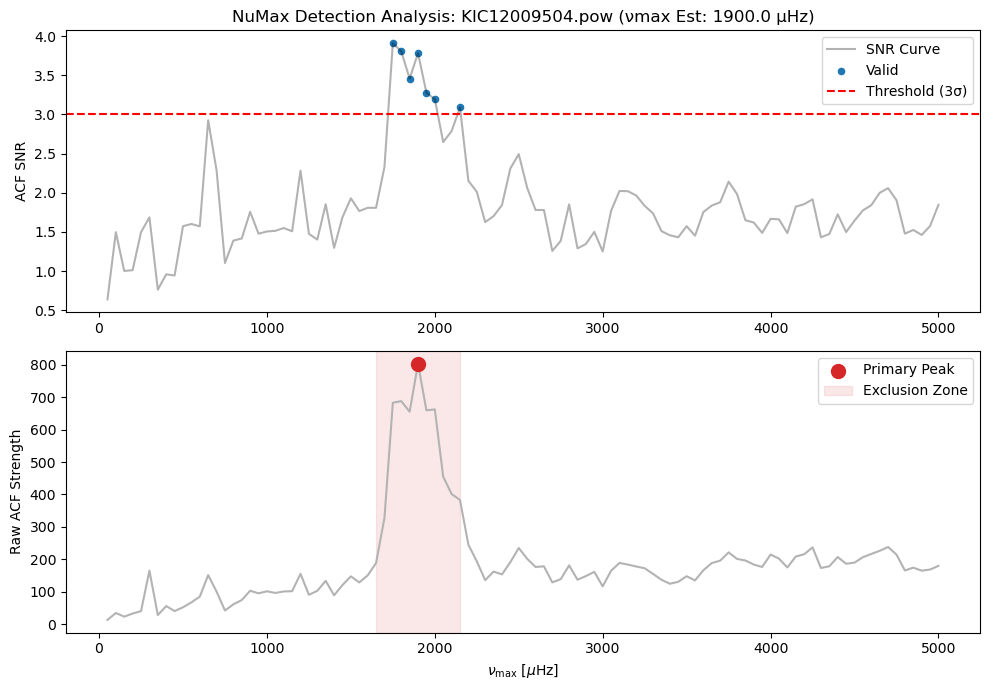

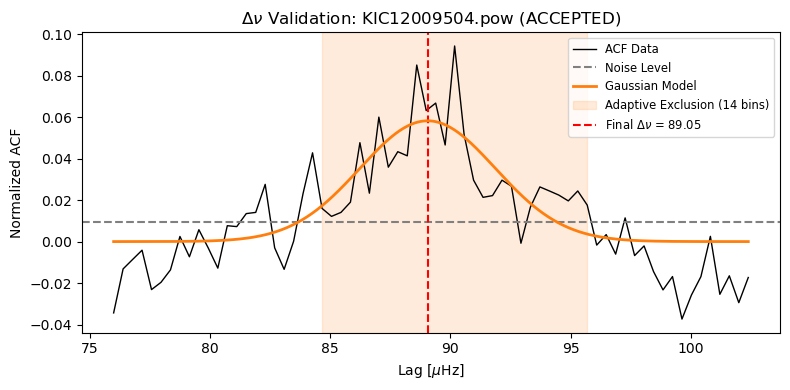

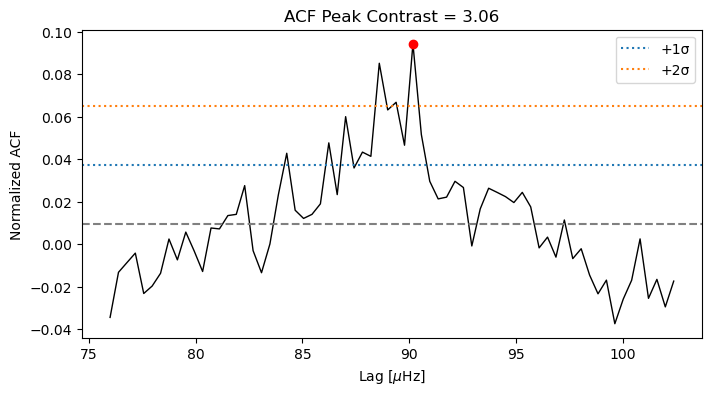

In [14]:
# --- DIAGNOSTIC PLOTTING FOR STAR 3 (KIC12009504) ---
staridx = 2
# Find the diagnostic dictionary for Star 3
# Index 2 corresponds to the 3rd star in your real_files list
star_name, detected, case = real_results[staridx]

print(f"Analyzing {star_name}...")
print(f"Status: {case['status']}")
print(f"Contrast: {case['peak_contrast']:.2f} (Threshold: 2.0)")
print(f"Ratio: {case['peak_ratio']:.2f} (Threshold: 1.2)")
# Assuming 'case' is your dictionary:
print(f"Δν = {case['dnu_final']:.3f} ± {case['popt'][2]/case['peak_contrast']:.3f} μHz") if case['dnu_final'] else print("No detection.")


# --- PLOT 1: NuMax Search Logic ---
plt.figure(figsize=(10, 7))

# Top: SNR of the sliding ACF
plt.subplot(2, 1, 1)
plt.plot(case["numax_grid"], case["acf_snr"], color="black", alpha=0.3, label="SNR Curve")
plt.scatter(case["numax_grid"][case["valid"]], case["acf_snr"][case["valid"]], color="C0", s=20, label="Valid")
plt.axhline(3, ls="--", color="red", label="Threshold (3σ)")
plt.ylabel("ACF SNR")
plt.title(f"NuMax Detection Analysis: {star_name} (νmax Est: {case['numax_est']:.1f} μHz)")
plt.legend()

# Bottom: Raw ACF strength
plt.subplot(2, 1, 2)
plt.plot(case["numax_grid"], case["acf_raw"], color="0.7")
plt.scatter(case["numax_grid"][case["imax"]], case["acf_raw"][case["imax"]], color="C3", s=100, zorder=5, label="Primary Peak")

# Highlight the exclusion zone around the primary peak
exc = case["exclude"]
idx = case["imax"]
plt.axvspan(case["numax_grid"][max(0, idx-exc)], 
            case["numax_grid"][min(len(case["numax_grid"])-1, idx+exc)], 
            color="C3", alpha=0.1, label="Exclusion Zone")

plt.xlabel(r"$\nu_{\max}$ [$\mu$Hz]")
plt.ylabel("Raw ACF Strength")
plt.legend()
plt.tight_layout()
plt.show()

# --- PLOT 2: Dnu Search & Gaussian Fit ---
plt.figure(figsize=(8, 4))
plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k", label="ACF Data", zorder=2)
plt.axhline(case["noise_level"], color="grey", ls="--", label="Noise Level")

# 1. Show the Gaussian Fit
if case["popt"] is not None and any(case["popt"]):
    lags_smooth = np.linspace(case["lags_fit"].min(), case["lags_fit"].max(), 500)
    fit_curve = gaussian(lags_smooth, *case["popt"])
    plt.plot(lags_smooth, fit_curve, color="C1", lw=2, label="Gaussian Model", zorder=3)

# 2. Highlight the ADAPTIVE Exclusion Zone
exc = case["exclude_dnu"]
idx = case["imax_dnu"]
lags_fit = case["lags_fit"]

# Calculate the actual lag values for the shading
low_bound = lags_fit[max(0, idx - exc)]
high_bound = lags_fit[min(len(lags_fit) - 1, idx + exc)]

plt.axvspan(low_bound, high_bound, color="C1", alpha=0.15, label=f"Adaptive Exclusion ({exc} bins)")

# 3. Mark the final detection
if case["dnu_final"] is not None:
    plt.axvline(case["dnu_final"], color="r", ls="--", label=rf"Final $\Delta\nu$ = {case['dnu_final']:.2f}")

plt.title(rf"$\Delta\nu$ Validation: {star_name} ({case['status']})")
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalized ACF")
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

# --- PLOT 3: Significance/Contrast ---
plt.figure(figsize=(8, 4))
plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k")
nl, ns = case["noise_level"], case["noise_sigma"]
plt.axhline(nl, color="grey", ls="--")
plt.axhline(nl + ns, ls=":", color="C0", label="+1σ")
plt.axhline(nl + 2*ns, ls=":", color="C1", label="+2σ")
plt.plot(case["lags_fit"][np.argmax(case["acf_fit"])], case["peak_main"], "ro")

plt.title(rf"ACF Peak Contrast = {case['peak_contrast']:.2f}")
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalized ACF")
plt.legend()
plt.show()

Noise Signal Analysis
Status: REJECTED: no SNR peak


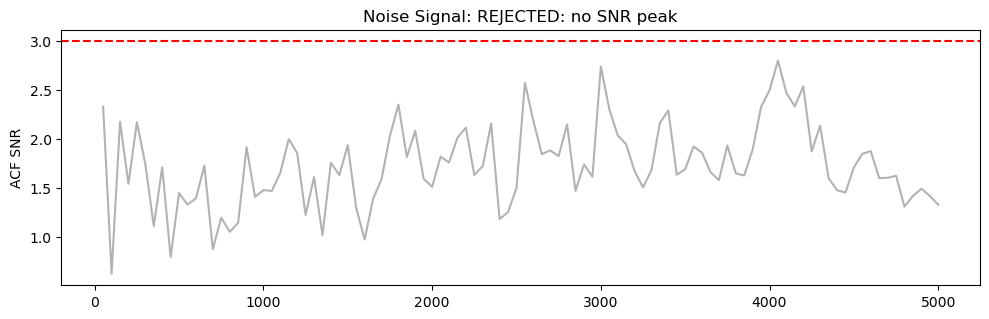

Skipping Δν plot: Pipeline stopped at step: REJECTED: no SNR peak


In [15]:
# --- PLOT DIAGNOSTICS FOR A REJECTED NOISE SIGNAL ---
noise_signal = fake[0]
detected, case = run_full_pipeline(freq, noise_signal, return_diagnostics=True)

print(f"Noise Signal Analysis")
print(f"Status: {case.get('status', 'Unknown')}")

# --- Plot 1: NuMax Search (The first hurdle) ---
plt.figure(figsize=(10, 6))
# Check if NuMax data exists
if "numax_grid" in case and "acf_snr" in case:
    plt.subplot(2, 1, 1)
    plt.plot(case["numax_grid"], case["acf_snr"], color="black", alpha=0.3)
    plt.axhline(3, ls="--", color="red", label="3σ Threshold")
    plt.ylabel("ACF SNR")
    plt.title(f"Noise Signal: {case.get('status')}")

    if "acf_raw" in case:
        plt.subplot(2, 1, 2)
        plt.plot(case["numax_grid"], case["acf_raw"], color="0.7")
        if "imax" in case:
            plt.scatter(case["numax_grid"][case["imax"]], case["acf_raw"][case["imax"]], 
                        color="C3", label="Highest Noise Peak")
        plt.xlabel(r"$\nu_{\max}$ [$\mu$Hz]")
        plt.ylabel("Raw ACF Strength")
        plt.legend()
else:
    print("Signal failed so early that even NuMax grid data is missing.")

plt.tight_layout()
plt.show()

# --- Plot 2: Delta Nu Search (The second hurdle) ---
# Only attempt to plot if the code actually performed the Dnu search
if "lags_fit" in case and "acf_fit" in case:
    plt.figure(figsize=(8, 4))
    plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k", label="Noise ACF")
    
    # Safely get Dnu parameters
    exc = case.get("exclude_dnu", 5)
    idx = case.get("imax_dnu", 0)
    lags_fit = case["lags_fit"]
    
    # Highlight exclusion zone
    if idx < len(lags_fit):
        low_b = lags_fit[max(0, idx - exc)]
        high_b = lags_fit[min(len(lags_fit) - 1, idx + exc)]
        plt.axvspan(low_b, high_b, color="gray", alpha=0.2, label="Exclusion Zone")

    # Show the Gaussian fit if it was attempted
    popt = case.get("popt")
    if popt is not None and any(popt):
        lags_smooth = np.linspace(lags_fit.min(), lags_fit.max(), 500)
        plt.plot(lags_smooth, gaussian(lags_smooth, *popt), color="C1", ls="--", label="Failed/Poor Fit")

    contrast = case.get('peak_contrast', 0.0)
    plt.title(f"ACF of Noise (Contrast: {contrast:.2f})")
    plt.xlabel(r"Lag [$\mu$Hz]")
    plt.ylabel("Normalized ACF")
    plt.legend()
    plt.show()
else:
    print(f"Skipping Δν plot: Pipeline stopped at step: {case.get('status')}")